# EEG_16 — Subject Clustering da Grafi e Ipergrafi

**Obiettivo**: raggruppare i soggetti in base alle loro feature EEG strutturali
(matrice di adiacenza media per i grafi; matrice di co-membership H·Hᵀ per gli ipergrafi),
poi verificare *a posteriori* se i cluster trovati si allineano con la bAcc dei modelli.

**Pipeline**:
1. Feature per soggetto: vettorizzazione upper-triangle della matrice media (grafo o ipergrafo)
2. Standardizzazione + PCA
3. K-Means k=2,3,4 — selezione k con silhouette
4. Post-hoc: overlay bAcc per interpretare i cluster

In [18]:
import json, logging, math, re
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.stats import mannwhitneyu
from tqdm.auto import tqdm

logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s %(levelname)-8s %(message)s',
                    datefmt='%H:%M:%S')
log = logging.getLogger('eeg16')

project_root = next((p for p in [Path.cwd()] + list(Path.cwd().parents)
                     if (p / '.git').exists()), Path.cwd())
FIG_DIR  = project_root / 'figures'; FIG_DIR.mkdir(exist_ok=True)
CKPT_DIR = project_root / 'models' / 'eeg16'; CKPT_DIR.mkdir(parents=True, exist_ok=True)

ACC_FILE_12 = project_root / 'figures' / 'eeg12_subject_ranking.csv'
ACC_FILE_13 = project_root / 'figures' / 'eeg13b_subject_ranking.csv'

METRIC      = 'abs_pcc'
N_CHAN      = 61
N_TRIU      = N_CHAN * (N_CHAN - 1) // 2   # 1830
K_RANGE     = [2, 3, 4]
RANDOM_SEED = 42

log.info(f'project_root = {project_root}')
log.info(f'Metrica: {METRIC} | N_TRIU: {N_TRIU}')

14:55:48 INFO     project_root = /home/daniele_u/miralis-hypergraph-imagined-speech
14:55:48 INFO     Metrica: abs_pcc | N_TRIU: 1830


## §1 — Caricamento feature per soggetto

Per ogni soggetto: media di tutti i trial (tutte le sessioni).
- **Grafo**: `d['adj']` → upper triangle → vettore 1830-dim
- **Ipergrafo**: `d['H'] @ d['H'].T` → upper triangle → vettore 1830-dim

In [19]:
_PAT = re.compile(r'^P(\d+)_S(\d+)$')

def build_index(metric):
    root = project_root / 'data' / f'hypergraphs_pruned_{metric}'
    idx  = defaultdict(list)
    if not root.exists():
        log.warning(f'Directory non trovata: {root}')
        return idx
    for p in sorted(root.rglob('trial_*.pt')):
        m = _PAT.match(p.parent.name)
        if m:
            idx[int(m.group(1))].append(p)
    return idx

IDX      = build_index(METRIC)
ALL_SUBJ = sorted(IDX.keys())
log.info(f'Soggetti trovati: {len(ALL_SUBJ)}')

GRAPH_CACHE = CKPT_DIR / f'feat_graph_{METRIC}.npz'
HG_CACHE    = CKPT_DIR / f'feat_hg_{METRIC}.npz'
triu_idx    = np.triu_indices(N_CHAN, k=1)

if GRAPH_CACHE.exists() and HG_CACHE.exists():
    log.info('Cache trovata — caricamento veloce')
    _g = np.load(GRAPH_CACHE); FEAT_G = _g['feats']; SUBJ_G = _g['subj_ids'].tolist()
    _h = np.load(HG_CACHE);    FEAT_H = _h['feats']; SUBJ_H = _h['subj_ids'].tolist()
else:
    feat_g, feat_h = [], []
    subj_g, subj_h = [], []

    for sid in tqdm(ALL_SUBJ, desc='Soggetti'):
        paths = IDX[sid]
        if len(paths) < 10:
            continue
        adjs, hhts = [], []
        for p in paths:
            try:
                d = torch.load(p, weights_only=False)
                adj = d['adj'].float().numpy()
                if adj.shape != (N_CHAN, N_CHAN):
                    continue
                adjs.append(adj)
                if 'H' in d:
                    H = d['H'].float().numpy()
                    hhts.append(H @ H.T)
            except Exception:
                continue
        if len(adjs) >= 10:
            feat_g.append(np.mean(adjs, axis=0)[triu_idx])
            subj_g.append(sid)
        if len(hhts) >= 10:
            feat_h.append(np.mean(hhts, axis=0)[triu_idx])
            subj_h.append(sid)

    FEAT_G, FEAT_H = np.array(feat_g), np.array(feat_h)
    SUBJ_G, SUBJ_H = subj_g, subj_h
    np.savez(GRAPH_CACHE, feats=FEAT_G, subj_ids=np.array(SUBJ_G))
    np.savez(HG_CACHE,    feats=FEAT_H, subj_ids=np.array(SUBJ_H))
    log.info('Cache salvata')

log.info(f'Grafi:     {FEAT_G.shape} — {len(SUBJ_G)} soggetti')
log.info(f'Ipergrafi: {FEAT_H.shape} — {len(SUBJ_H)} soggetti')

14:55:49 INFO     Soggetti trovati: 74
14:55:49 INFO     Cache trovata — caricamento veloce
14:55:49 INFO     Grafi:     (74, 1830) — 74 soggetti
14:55:49 INFO     Ipergrafi: (74, 1830) — 74 soggetti


## §2 — Clustering su feature GRAFO

StandardScaler → PCA 20 componenti → K-Means k=2,3,4 → silhouette per scegliere k ottimale.

14:55:49 INFO     Varianza spiegata PCA grafo (20 comp): 67.5%
14:55:49 INFO       Grafo k=2: silhouette=0.236
14:55:49 INFO       Grafo k=3: silhouette=0.246
14:55:49 INFO       Grafo k=4: silhouette=0.246
14:55:49 INFO     k ottimale grafo: 4  (silhouette=0.246)


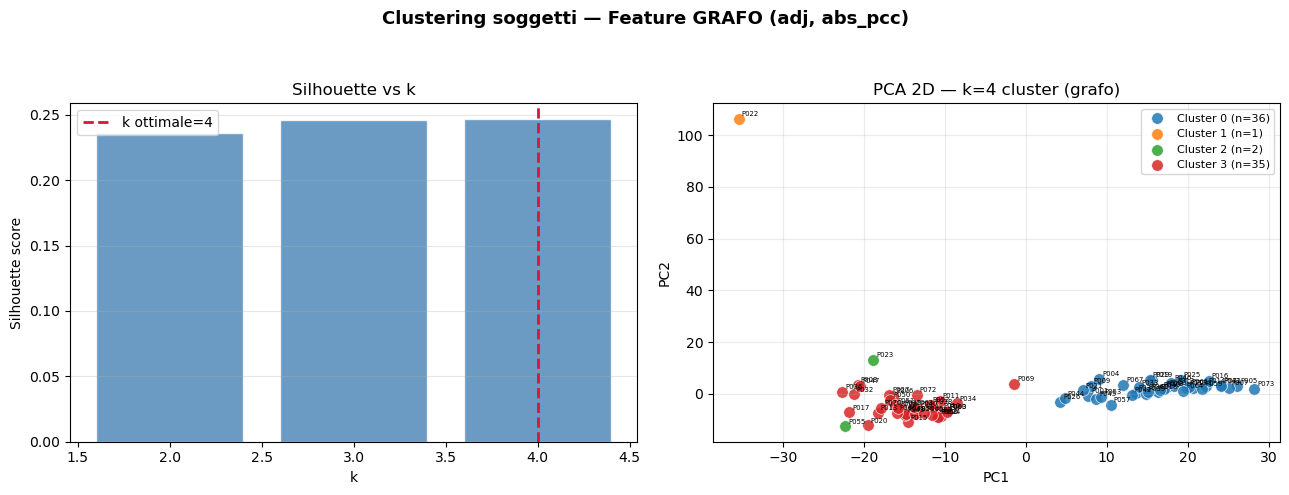

In [20]:
scaler_g = StandardScaler()
X_g = scaler_g.fit_transform(FEAT_G)
pca_g = PCA(n_components=min(20, len(SUBJ_G) - 1), random_state=RANDOM_SEED)
Z_g   = pca_g.fit_transform(X_g)
log.info(f'Varianza spiegata PCA grafo (20 comp): {pca_g.explained_variance_ratio_.sum():.1%}')

sil_g = {}
for k in K_RANGE:
    if k >= len(SUBJ_G):
        continue
    lbl = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_SEED).fit_predict(Z_g)
    sil_g[k] = silhouette_score(Z_g, lbl)
    log.info(f'  Grafo k={k}: silhouette={sil_g[k]:.3f}')

k_best_g = max(sil_g, key=sil_g.get)
LABELS_G  = KMeans(n_clusters=k_best_g, n_init=30, random_state=RANDOM_SEED).fit_predict(Z_g)
log.info(f'k ottimale grafo: {k_best_g}  (silhouette={sil_g[k_best_g]:.3f})')

PALETTE_G = plt.cm.tab10(np.linspace(0, 0.35, k_best_g))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Clustering soggetti — Feature GRAFO (adj, {METRIC})', fontsize=13, fontweight='bold')

ax = axes[0]
ax.bar(list(sil_g.keys()), list(sil_g.values()), color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(k_best_g, color='crimson', linestyle='--', linewidth=2, label=f'k ottimale={k_best_g}')
ax.set_xlabel('k'); ax.set_ylabel('Silhouette score'); ax.set_title('Silhouette vs k')
ax.legend(); ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
for c in range(k_best_g):
    mask = LABELS_G == c
    ax2.scatter(Z_g[mask, 0], Z_g[mask, 1], label=f'Cluster {c} (n={mask.sum()})',
                s=70, alpha=0.85, color=PALETTE_G[c], edgecolors='white', linewidths=0.5)
    for i in np.where(mask)[0]:
        ax2.annotate(f'P{SUBJ_G[i]:03d}', (Z_g[i, 0], Z_g[i, 1]),
                     fontsize=5, xytext=(2, 2), textcoords='offset points')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')
ax2.set_title(f'PCA 2D — k={k_best_g} cluster (grafo)')
ax2.legend(fontsize=8); ax2.grid(alpha=0.25)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(FIG_DIR / 'eeg16_clustering_graph.png', dpi=150, bbox_inches='tight')
plt.show()

## §3 — Clustering su feature IPERGRAFO

Stessa pipeline su H·Hᵀ (matrice di co-membership degli iper-archi, unica proprietà degli ipergrafi rispetto ai grafi semplici).

14:55:50 INFO     Varianza spiegata PCA ipergrafo (20 comp): 70.7%
14:55:51 INFO       Ipergrafo k=2: silhouette=0.284
14:55:51 INFO       Ipergrafo k=3: silhouette=0.288
14:55:51 INFO       Ipergrafo k=4: silhouette=0.251
14:55:51 INFO     k ottimale ipergrafo: 3  (silhouette=0.288)


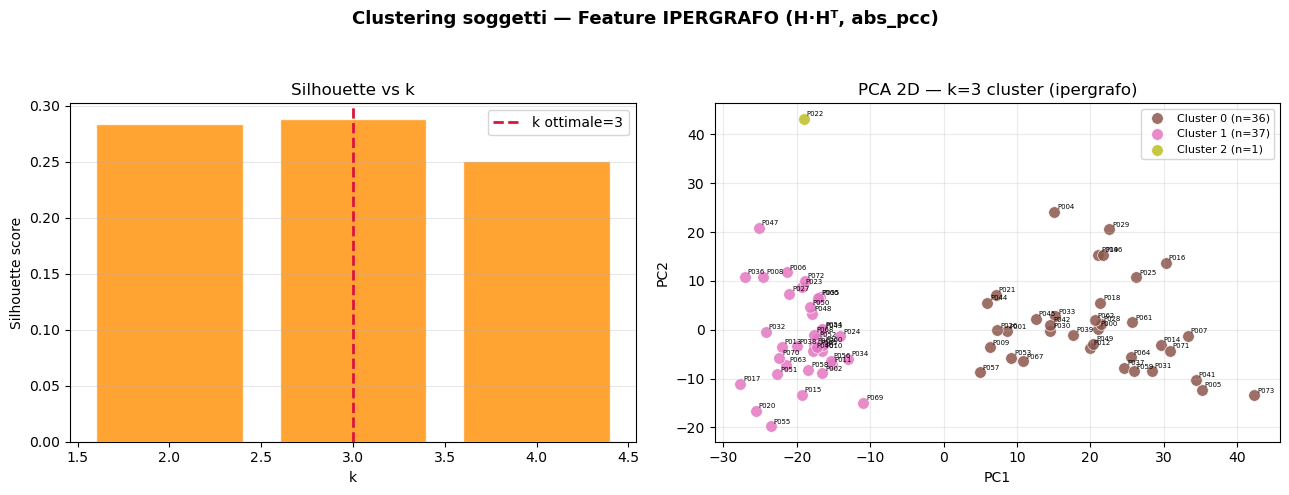

In [21]:
scaler_h = StandardScaler()
X_h = scaler_h.fit_transform(FEAT_H)
pca_h = PCA(n_components=min(20, len(SUBJ_H) - 1), random_state=RANDOM_SEED)
Z_h   = pca_h.fit_transform(X_h)
log.info(f'Varianza spiegata PCA ipergrafo (20 comp): {pca_h.explained_variance_ratio_.sum():.1%}')

sil_h = {}
for k in K_RANGE:
    if k >= len(SUBJ_H):
        continue
    lbl = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_SEED).fit_predict(Z_h)
    sil_h[k] = silhouette_score(Z_h, lbl)
    log.info(f'  Ipergrafo k={k}: silhouette={sil_h[k]:.3f}')

k_best_h = max(sil_h, key=sil_h.get)
LABELS_H  = KMeans(n_clusters=k_best_h, n_init=30, random_state=RANDOM_SEED).fit_predict(Z_h)
log.info(f'k ottimale ipergrafo: {k_best_h}  (silhouette={sil_h[k_best_h]:.3f})')

PALETTE_H = plt.cm.tab10(np.linspace(0.5, 0.85, k_best_h))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Clustering soggetti — Feature IPERGRAFO (H·Hᵀ, {METRIC})', fontsize=13, fontweight='bold')

ax = axes[0]
ax.bar(list(sil_h.keys()), list(sil_h.values()), color='darkorange', alpha=0.8, edgecolor='white')
ax.axvline(k_best_h, color='crimson', linestyle='--', linewidth=2, label=f'k ottimale={k_best_h}')
ax.set_xlabel('k'); ax.set_ylabel('Silhouette score'); ax.set_title('Silhouette vs k')
ax.legend(); ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
for c in range(k_best_h):
    mask = LABELS_H == c
    ax2.scatter(Z_h[mask, 0], Z_h[mask, 1], label=f'Cluster {c} (n={mask.sum()})',
                s=70, alpha=0.85, color=PALETTE_H[c], edgecolors='white', linewidths=0.5)
    for i in np.where(mask)[0]:
        ax2.annotate(f'P{SUBJ_H[i]:03d}', (Z_h[i, 0], Z_h[i, 1]),
                     fontsize=5, xytext=(2, 2), textcoords='offset points')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')
ax2.set_title(f'PCA 2D — k={k_best_h} cluster (ipergrafo)')
ax2.legend(fontsize=8); ax2.grid(alpha=0.25)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(FIG_DIR / 'eeg16_clustering_hypergraph.png', dpi=150, bbox_inches='tight')
plt.show()

## §4 — Caricamento bAcc post-hoc

In [22]:
acc_data = {}
for label, fpath in [('EEG_12', ACC_FILE_12), ('EEG_13', ACC_FILE_13)]:
    if fpath.exists():
        df = pd.read_csv(fpath)
        if 'Subject' in df.columns:
            df['sid'] = df['Subject'].str.extract(r'(\d+)').astype(int)
        col = 'Test bAcc' if 'Test bAcc' in df.columns else 'test_bacc'
        acc_data[label] = dict(zip(df['sid'], df[col]))
        log.info(f'{label}: {len(acc_data[label])} soggetti')
    else:
        log.warning(f'{label} non trovato')

acc12 = acc_data.get('EEG_12', {})
acc13 = acc_data.get('EEG_13', {})
ACC   = acc13 if acc13 else acc12
log.info(f'Accuracy primaria: {"EEG_13" if acc13 else "EEG_12"} ({len(ACC)} soggetti)')

14:55:53 INFO     EEG_12: 73 soggetti
14:55:53 INFO     EEG_13: 73 soggetti
14:55:53 INFO     Accuracy primaria: EEG_13 (73 soggetti)


## §5 — Post-hoc: cluster GRAFO vs bAcc

Boxplot bAcc per cluster + PCA 2D colorato per bAcc + Mann-Whitney U tra coppie di cluster.

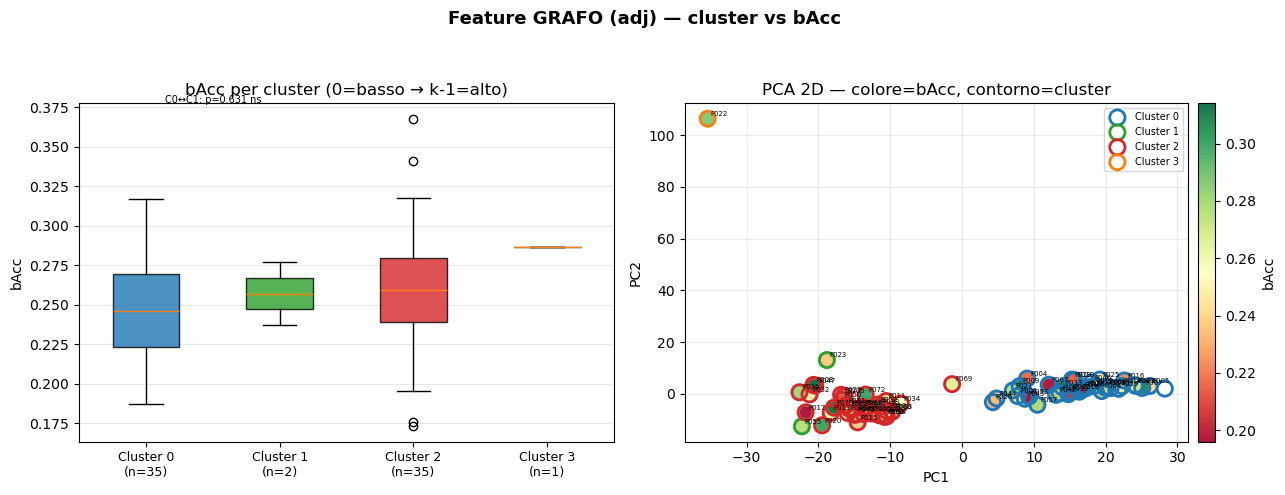

In [23]:
def postHoc(labels, subj_ids, Z, palette, acc_dict, source_name, save_stem):
    k = len(set(labels))
    clust_accs = defaultdict(list)
    for i, sid in enumerate(subj_ids):
        if sid in acc_dict:
            clust_accs[labels[i]].append(acc_dict[sid])

    # Riordina cluster per acc media crescente
    order  = sorted(clust_accs, key=lambda c: np.mean(clust_accs[c]) if clust_accs[c] else 0)
    remap  = {old: new for new, old in enumerate(order)}
    lbl_r  = np.array([remap[l] for l in labels])
    acc_r  = {remap[c]: v for c, v in clust_accs.items()}
    pal_r  = [palette[order[c]] for c in range(k)]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'{source_name} — cluster vs bAcc', fontsize=13, fontweight='bold')

    # ── Boxplot ───────────────────────────────────────────────────────────────
    ax = axes[0]
    bp = ax.boxplot([acc_r.get(c, []) for c in range(k)],
                    patch_artist=True, widths=0.5, notch=False)
    for patch, col in zip(bp['boxes'], pal_r):
        patch.set_facecolor(col); patch.set_alpha(0.8)
    ax.set_xticklabels([f'Cluster {c}\n(n={len(acc_r.get(c,[]))})' for c in range(k)], fontsize=9)
    ax.set_ylabel('bAcc'); ax.set_title('bAcc per cluster (0=basso → k-1=alto)')
    ax.grid(axis='y', alpha=0.3)

    # Annotazione p-value Mann-Whitney
    all_vals = [v for vlist in acc_r.values() for v in vlist]
    y_top = max(all_vals) + 0.01 if all_vals else 0.4
    pairs = [(ci, cj) for ci in range(k) for cj in range(ci + 1, k)]
    for offset, (ci, cj) in enumerate(pairs):
        a, b = acc_r.get(ci, []), acc_r.get(cj, [])
        if len(a) >= 2 and len(b) >= 2:
            _, pval = mannwhitneyu(a, b, alternative='two-sided')
            star = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
            y = y_top + offset * 0.018
            ax.annotate(f'C{ci}↔C{cj}: p={pval:.3f} {star}',
                        xy=(1.5, y), fontsize=7, ha='center', color='black')

    # ── PCA 2D colorato per bAcc ──────────────────────────────────────────────
    ax2 = axes[1]
    accs_vec = np.array([acc_dict.get(sid, np.nan) for sid in subj_ids])
    valid    = ~np.isnan(accs_vec)
    sc = ax2.scatter(Z[valid, 0], Z[valid, 1], c=accs_vec[valid],
                     cmap='RdYlGn', s=80, alpha=0.9,
                     vmin=np.nanpercentile(accs_vec, 5),
                     vmax=np.nanpercentile(accs_vec, 95),
                     edgecolors='grey', linewidths=0.4)
    plt.colorbar(sc, ax=ax2, label='bAcc', fraction=0.04, pad=0.02)
    # Contorno cluster
    for c in range(k):
        mask = lbl_r == c
        ax2.scatter(Z[mask, 0], Z[mask, 1], s=120, facecolors='none',
                    edgecolors=pal_r[c], linewidths=2, label=f'Cluster {c}', zorder=3)
    for i in range(len(subj_ids)):
        if valid[i]:
            ax2.annotate(f'P{subj_ids[i]:03d}', (Z[i, 0], Z[i, 1]),
                         fontsize=5, xytext=(2, 2), textcoords='offset points')
    ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')
    ax2.set_title('PCA 2D — colore=bAcc, contorno=cluster')
    ax2.legend(fontsize=7); ax2.grid(alpha=0.25)

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.savefig(FIG_DIR / f'{save_stem}.png', dpi=150, bbox_inches='tight')
    plt.show()
    return lbl_r

LABELS_G_R = postHoc(LABELS_G, SUBJ_G, Z_g, PALETTE_G, ACC,
                     'Feature GRAFO (adj)', 'eeg16_graph_vs_bacc')

## §6 — Post-hoc: cluster IPERGRAFO vs bAcc

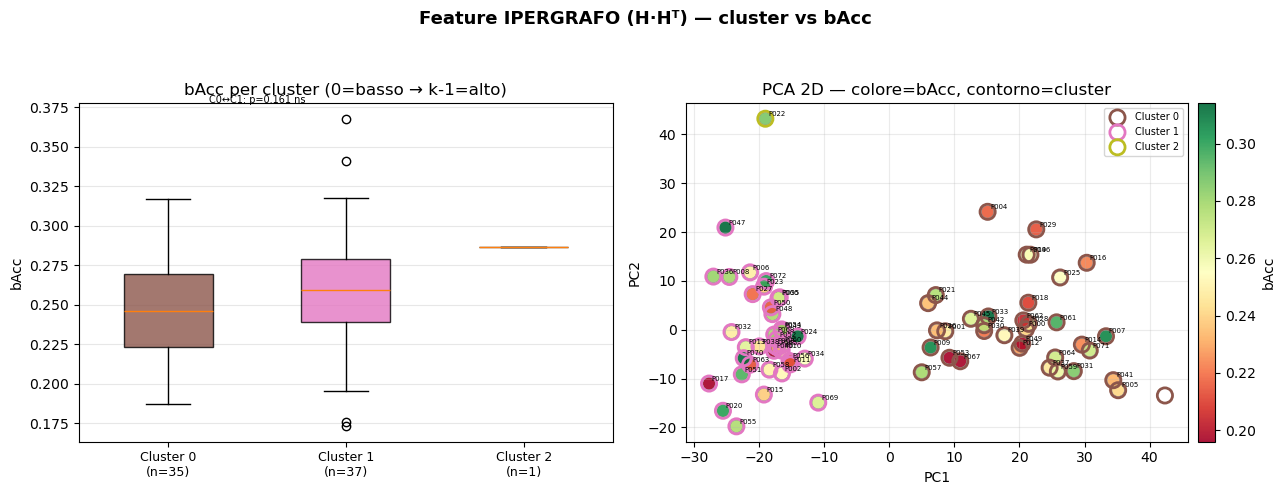

In [24]:
LABELS_H_R = postHoc(LABELS_H, SUBJ_H, Z_h, PALETTE_H, ACC,
                     'Feature IPERGRAFO (H·Hᵀ)', 'eeg16_hypergraph_vs_bacc')

## §7 — Concordanza clustering grafo vs ipergrafo

Adjusted Rand Index (ARI): quanto concordano i due clustering sugli stessi soggetti.

14:55:59 INFO     Soggetti in comune grafo ∩ ipergrafo: 74
14:55:59 INFO     ARI (grafo vs ipergrafo): 0.948


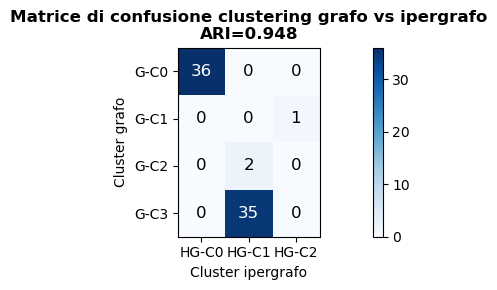

In [25]:
common = sorted(set(SUBJ_G) & set(SUBJ_H))
log.info(f'Soggetti in comune grafo ∩ ipergrafo: {len(common)}')

lbl_g_common = np.array([LABELS_G[SUBJ_G.index(s)] for s in common])
lbl_h_common = np.array([LABELS_H[SUBJ_H.index(s)] for s in common])
ari = adjusted_rand_score(lbl_g_common, lbl_h_common)
log.info(f'ARI (grafo vs ipergrafo): {ari:.3f}')

fig, ax = plt.subplots(figsize=(max(k_best_g, k_best_h) * 2.5 + 1, 3))
cm = np.zeros((k_best_g, k_best_h), dtype=int)
for g, h in zip(lbl_g_common, lbl_h_common):
    cm[g, h] += 1
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(k_best_h)); ax.set_xticklabels([f'HG-C{c}' for c in range(k_best_h)])
ax.set_yticks(range(k_best_g)); ax.set_yticklabels([f'G-C{c}' for c in range(k_best_g)])
ax.set_xlabel('Cluster ipergrafo'); ax.set_ylabel('Cluster grafo')
ax.set_title(f'Matrice di confusione clustering grafo vs ipergrafo\nARI={ari:.3f}', fontweight='bold')
for i in range(k_best_g):
    for j in range(k_best_h):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=12,
                color='white' if cm[i, j] > cm.max() * 0.6 else 'black')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg16_ari_graph_vs_hypergraph.png', dpi=150, bbox_inches='tight')
plt.show()

## §8 — Tabella riassuntiva soggetti

In [26]:
rows = []
for sid in sorted(set(SUBJ_G) | set(SUBJ_H)):
    row = {'Subject': f'P{sid:03d}',
           'cluster_graph':     LABELS_G[SUBJ_G.index(sid)] if sid in SUBJ_G else np.nan,
           'cluster_hypergraph':LABELS_H[SUBJ_H.index(sid)] if sid in SUBJ_H else np.nan,
           'bacc_EEG_12': acc12.get(sid, np.nan),
           'bacc_EEG_13': acc13.get(sid, np.nan)}
    rows.append(row)

df_summary = pd.DataFrame(rows)
df_summary.to_csv(FIG_DIR / 'eeg16_subject_cluster_summary.csv', index=False)

# Stampa con colorazione manuale
display_df = df_summary.copy()
print(display_df.to_string(index=False, float_format='{:.4f}'.format))

# Statistiche per cluster grafo
print('\n── Statistiche bAcc per cluster GRAFO ──')
for c in sorted(df_summary['cluster_graph'].dropna().unique()):
    sub = df_summary[df_summary['cluster_graph'] == c]['bacc_EEG_13'].dropna()
    print(f'  Cluster {int(c)}: n={len(sub)}  mean={sub.mean():.3f}  std={sub.std():.3f}  '
          f'[{sub.min():.3f}, {sub.max():.3f}]')

print('\n── Statistiche bAcc per cluster IPERGRAFO ──')
for c in sorted(df_summary['cluster_hypergraph'].dropna().unique()):
    sub = df_summary[df_summary['cluster_hypergraph'] == c]['bacc_EEG_13'].dropna()
    print(f'  Cluster {int(c)}: n={len(sub)}  mean={sub.mean():.3f}  std={sub.std():.3f}  '
          f'[{sub.min():.3f}, {sub.max():.3f}]')

Subject  cluster_graph  cluster_hypergraph  bacc_EEG_12  bacc_EEG_13
   P000              0                   0       0.2731       0.2399
   P001              0                   0       0.2500       0.2474
   P002              3                   1       0.2973       0.2528
   P003              3                   1       0.2384       0.2791
   P004              0                   0       0.2546       0.2167
   P005              0                   0       0.2567       0.2414
   P006              3                   1       0.2396       0.2490
   P007              0                   0       0.2063       0.3064
   P008              3                   1       0.2871       0.2788
   P009              0                   0       0.2607       0.3062
   P010              3                   1       0.1984       0.2471
   P011              3                   1       0.2549       0.2391
   P012              0                   0       0.2500       0.2279
   P013              3            

## §9 — Visualizzazione top clustering: segnale raw, grafo, ipergrafo

Per la conformazione con silhouette più alta (grafo o ipergrafo), mostra per ogni cluster:
- **Col 1** — segnale EEG raw medio (canali × campioni, media trial e soggetti nel cluster)
- **Col 2** — matrice di adiacenza media del cluster (grafo)
- **Col 3** — matrice di co-membership H·Hᵀ media del cluster (ipergrafo)

In [27]:
# ── Scegli top clustering ─────────────────────────────────────────────────────
sil_top_g = sil_g[k_best_g]
sil_top_h = sil_h.get(k_best_h, 0)

if sil_top_g >= sil_top_h:
    LABELS_TOP, SUBJ_TOP, k_top = LABELS_G, SUBJ_G, k_best_g
    top_src = f'GRAFO (k={k_best_g}, sil={sil_top_g:.3f})'
else:
    LABELS_TOP, SUBJ_TOP, k_top = LABELS_H, SUBJ_H, k_best_h
    top_src = f'IPERGRAFO (k={k_best_h}, sil={sil_top_h:.3f})'
log.info(f'Top clustering: {top_src}')

# ── Matrici medie per cluster (grafo + ipergrafo) ────────────────────────────
triu_idx = np.triu_indices(N_CHAN, k=1)

def vec_to_sym(vec):
    M = np.zeros((N_CHAN, N_CHAN))
    M[triu_idx] = vec
    return M + M.T

cluster_adj = {}
cluster_hht = {}
for c in range(k_top):
    subj_c = [SUBJ_TOP[i] for i in range(len(SUBJ_TOP)) if LABELS_TOP[i] == c]
    adjs_c = [vec_to_sym(FEAT_G[SUBJ_G.index(s)]) for s in subj_c if s in SUBJ_G]
    hhts_c = [vec_to_sym(FEAT_H[SUBJ_H.index(s)]) for s in subj_c if s in SUBJ_H]
    cluster_adj[c] = np.mean(adjs_c, axis=0) if adjs_c else None
    cluster_hht[c] = np.mean(hhts_c, axis=0) if hhts_c else None
    log.info(f'  Cluster {c}: {len(subj_c)} soggetti  (adj={len(adjs_c)} hht={len(hhts_c)})')

# ── Segnale raw medio per soggetto (cache) ────────────────────────────────────
RAW_CACHE = CKPT_DIR / 'mean_raw_per_subject.npz'
N_SAMP    = 384
raw_root  = project_root / 'data' / 'raw_csv' / 'training_set'

if RAW_CACHE.exists():
    log.info('Cache raw trovata')
    _r = np.load(RAW_CACHE)
    MEAN_RAW = _r['mean_raw']        # (n_subj, 61, 384)
    SUBJ_RAW = _r['subj_ids'].tolist()
else:
    mean_raw_list, subj_raw_list = [], []
    for sid in tqdm(ALL_SUBJ, desc='Raw EEG'):
        pat_dirs = sorted(raw_root.glob(f'P{sid:03d}_S*'))
        trials = []
        for pat_dir in pat_dirs:
            for csv_f in sorted(pat_dir.glob('*_img.csv'))[:15]:
                try:
                    x = pd.read_csv(csv_f, header=None).values.astype(np.float32)
                    if x.shape == (N_CHAN, N_SAMP):
                        trials.append(x)
                except Exception:
                    continue
        if len(trials) >= 5:
            mean_raw_list.append(np.mean(trials, axis=0))
            subj_raw_list.append(sid)
    MEAN_RAW = np.array(mean_raw_list)
    SUBJ_RAW = subj_raw_list
    np.savez(RAW_CACHE, mean_raw=MEAN_RAW, subj_ids=np.array(SUBJ_RAW))
    log.info(f'Cache raw salvata: {MEAN_RAW.shape}')

cluster_raw = {}
for c in range(k_top):
    subj_c = [SUBJ_TOP[i] for i in range(len(SUBJ_TOP)) if LABELS_TOP[i] == c]
    raws_c = [MEAN_RAW[SUBJ_RAW.index(s)] for s in subj_c if s in SUBJ_RAW]
    cluster_raw[c] = np.mean(raws_c, axis=0) if raws_c else None
    log.info(f'  Cluster {c}: {len(raws_c)} soggetti con raw')


14:55:59 INFO     Top clustering: IPERGRAFO (k=3, sil=0.288)
14:55:59 INFO       Cluster 0: 36 soggetti  (adj=36 hht=36)
14:55:59 INFO       Cluster 1: 37 soggetti  (adj=37 hht=37)
14:55:59 INFO       Cluster 2: 1 soggetti  (adj=1 hht=1)
14:55:59 INFO     Cache raw trovata
14:55:59 INFO       Cluster 0: 36 soggetti con raw
14:55:59 INFO       Cluster 1: 37 soggetti con raw
14:55:59 INFO       Cluster 2: 1 soggetti con raw


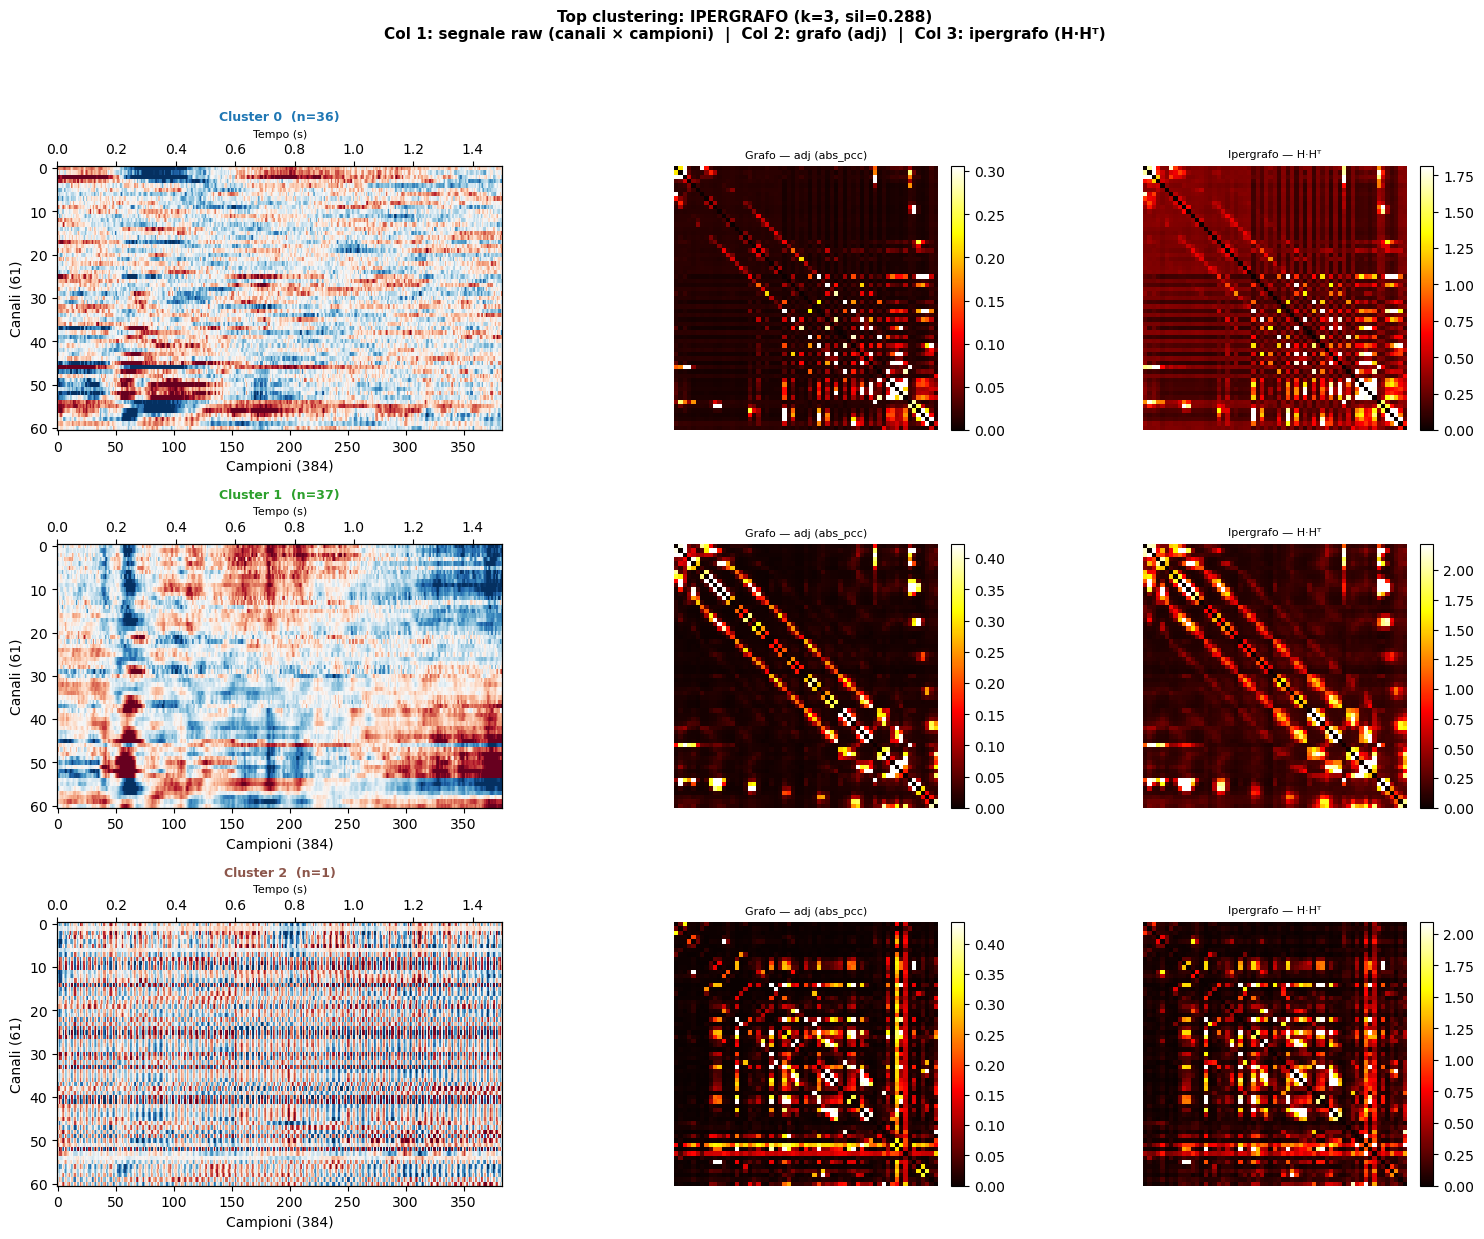

14:56:00 INFO     Plot §9 salvato


In [28]:
# ── Plot k × 3: raw | grafo | ipergrafo ──────────────────────────────────────
COLORS_TOP = plt.cm.tab10(np.linspace(0, 0.5, k_top))

fig, axes = plt.subplots(k_top, 3, figsize=(15, 4.2 * k_top))
fig.suptitle(
    f'Top clustering: {top_src}\n'
    f'Col 1: segnale raw (canali × campioni)  |  Col 2: grafo (adj)  |  Col 3: ipergrafo (H·Hᵀ)',
    fontsize=11, fontweight='bold'
)

for c in range(k_top):
    n_c   = int((LABELS_TOP == c).sum())
    color = COLORS_TOP[c]
    label = f'Cluster {c}  (n={n_c})'

    # ── Col 0: segnale raw ────────────────────────────────────────────────────
    ax0 = axes[c, 0]
    if cluster_raw[c] is not None:
        raw = cluster_raw[c]                          # (61, 384)
        vlim = np.percentile(np.abs(raw), 97)
        ax0.imshow(raw, aspect='auto', cmap='RdBu_r',
                   vmin=-vlim, vmax=vlim, interpolation='nearest')
        ax0.set_xlabel('Campioni (384)')
        ax0.set_ylabel('Canali (61)')
        t_ax = ax0.twiny()
        t_ax.set_xlim(0, N_SAMP / 256)
        t_ax.set_xlabel('Tempo (s)', fontsize=8)
    else:
        ax0.text(0.5, 0.5, 'N/D', ha='center', va='center', transform=ax0.transAxes)
    ax0.set_title(label, fontsize=9, color=color, fontweight='bold')

    # ── Col 1: grafo ──────────────────────────────────────────────────────────
    ax1 = axes[c, 1]
    if cluster_adj[c] is not None:
        adj = cluster_adj[c]
        im1 = ax1.imshow(adj, cmap='hot',
                         vmin=0, vmax=np.percentile(adj, 98),
                         interpolation='nearest')
        plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.03)
        ax1.set_title(f'Grafo — adj ({METRIC})', fontsize=8)
    ax1.axis('off')

    # ── Col 2: ipergrafo ──────────────────────────────────────────────────────
    ax2 = axes[c, 2]
    if cluster_hht[c] is not None:
        hht = cluster_hht[c]
        im2 = ax2.imshow(hht, cmap='hot',
                         vmin=0, vmax=np.percentile(hht, 98),
                         interpolation='nearest')
        plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.03)
        ax2.set_title('Ipergrafo — H·Hᵀ', fontsize=8)
    ax2.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(FIG_DIR / 'eeg16_top_cluster_raw_graph_hg.png', dpi=150, bbox_inches='tight')
plt.show()
log.info('Plot §9 salvato')


## §10 — Multi-metrica: clustering con wpli e plv

Ripete il clustering su `abs_pcc`, `wpli`, `plv`. Se ARI alto tra metriche → struttura robusta alla conduzione di volume. Se ARI basso → la separazione era artefattuale.

14:56:05 INFO     abs_pcc: cache caricata (74 soggetti)
14:56:05 INFO       abs_pcc: H·Hᵀ cache caricata (74 soggetti)
14:56:05 INFO       abs_pcc: k=4  sil=0.246
14:56:05 INFO     wpli: cache caricata (74 soggetti)
14:56:05 INFO       wpli: H·Hᵀ cache caricata (74 soggetti)
14:56:05 INFO       wpli: k=3  sil=0.281
14:56:05 INFO     plv: cache caricata (74 soggetti)
14:56:05 INFO       plv: calcolo H·Hᵀ...


plv H·Hᵀ:   0%|          | 0/74 [00:00<?, ?it/s]

14:56:36 INFO       plv: k=4  sil=0.292
14:56:36 INFO     ARI inter-metrica:
14:56:36 INFO       abs_pcc vs wpli: ARI=0.948
14:56:36 INFO       abs_pcc vs plv: ARI=0.922
14:56:36 INFO       wpli vs plv: ARI=0.921


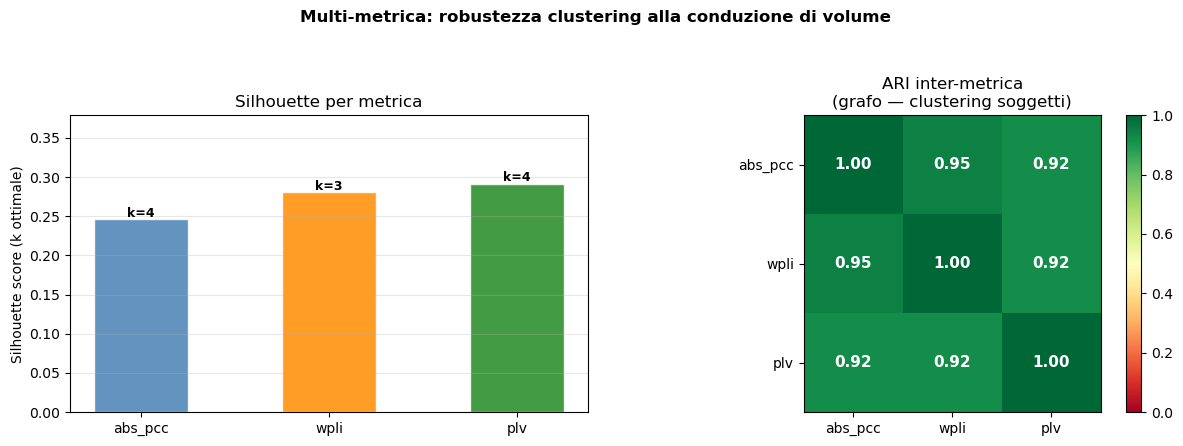

In [29]:
METRICS_COMPARE = ['abs_pcc', 'wpli', 'plv']
ALL_FEATS_G  = {}   # metric -> (feats, subj_ids)
ALL_FEATS_H  = {}   # metric -> (feats_hht, subj_ids)
ALL_LABELS_M = {}   # metric -> labels
ALL_SUBJ_M   = {}   # metric -> subj_ids
ALL_SIL_M    = {}   # metric -> best silhouette
ALL_K_M      = {}   # metric -> k_best

for m in METRICS_COMPARE:
    cache = CKPT_DIR / f'feat_graph_{m}.npz'
    if cache.exists():
        _c = np.load(cache)
        feats, subjs = _c['feats'], _c['subj_ids'].tolist()
        log.info(f'{m}: cache caricata ({len(subjs)} soggetti)')
    else:
        log.info(f'{m}: calcolo feature...')
        idx_m = build_index(m)
        feat_list, subj_list = [], []
        for sid in tqdm(sorted(idx_m.keys()), desc=m, leave=False):
            adjs = []
            for p in idx_m[sid]:
                try:
                    d = torch.load(p, weights_only=False)
                    adj = d['adj'].float().numpy()
                    if adj.shape == (N_CHAN, N_CHAN):
                        adjs.append(adj)
                except Exception:
                    continue
            if len(adjs) >= 10:
                feat_list.append(np.mean(adjs, axis=0)[triu_idx])
                subj_list.append(sid)
        feats = np.array(feat_list)
        subjs = subj_list
        np.savez(cache, feats=feats, subj_ids=np.array(subjs))
    ALL_FEATS_G[m] = (feats, subjs)

    # H·Hᵀ features per questa metrica
    hg_cache = CKPT_DIR / f'feat_hg_{m}.npz'
    if hg_cache.exists():
        _hc = np.load(hg_cache)
        hht_feats, hht_subjs = _hc['feats'], _hc['subj_ids'].tolist()
        log.info(f'  {m}: H·Hᵀ cache caricata ({len(hht_subjs)} soggetti)')
    else:
        log.info(f'  {m}: calcolo H·Hᵀ...')
        idx_m = build_index(m)
        hht_list, hht_subj_list = [], []
        for sid in tqdm(sorted(idx_m.keys()), desc=f'{m} H·Hᵀ', leave=False):
            hhts = []
            for p in idx_m[sid]:
                try:
                    d = torch.load(p, weights_only=False)
                    if 'H' in d:
                        H = d['H'].float().numpy()
                        hhts.append(H @ H.T)
                except Exception:
                    continue
            if len(hhts) >= 10:
                hht_list.append(np.mean(hhts, axis=0)[triu_idx])
                hht_subj_list.append(sid)
        hht_feats = np.array(hht_list)
        hht_subjs = hht_subj_list
        np.savez(hg_cache, feats=hht_feats, subj_ids=np.array(hht_subjs))
    ALL_FEATS_H[m] = (hht_feats, hht_subjs)

    # Clustering
    X = StandardScaler().fit_transform(feats)
    Z = PCA(n_components=min(20, len(subjs) - 1), random_state=RANDOM_SEED).fit_transform(X)
    sil_m = {}
    for k in K_RANGE:
        if k >= len(subjs):
            continue
        lbl = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_SEED).fit_predict(Z)
        sil_m[k] = silhouette_score(Z, lbl)
    k_b = max(sil_m, key=sil_m.get)
    labels = KMeans(n_clusters=k_b, n_init=30, random_state=RANDOM_SEED).fit_predict(Z)
    ALL_LABELS_M[m] = labels
    ALL_SUBJ_M[m]   = subjs
    ALL_SIL_M[m]    = sil_m[k_b]
    ALL_K_M[m]      = k_b
    log.info(f'  {m}: k={k_b}  sil={sil_m[k_b]:.3f}')

# ── ARI inter-metrica ─────────────────────────────────────────────────────────
n_m = len(METRICS_COMPARE)
ARI_MAT = np.zeros((n_m, n_m))
for i, m1 in enumerate(METRICS_COMPARE):
    for j, m2 in enumerate(METRICS_COMPARE):
        common = sorted(set(ALL_SUBJ_M[m1]) & set(ALL_SUBJ_M[m2]))
        l1 = np.array([ALL_LABELS_M[m1][ALL_SUBJ_M[m1].index(s)] for s in common])
        l2 = np.array([ALL_LABELS_M[m2][ALL_SUBJ_M[m2].index(s)] for s in common])
        ARI_MAT[i, j] = adjusted_rand_score(l1, l2)

log.info('ARI inter-metrica:')
for i, m1 in enumerate(METRICS_COMPARE):
    for j, m2 in enumerate(METRICS_COMPARE):
        if j > i:
            log.info(f'  {m1} vs {m2}: ARI={ARI_MAT[i,j]:.3f}')

# ── Plot ──────────────────────────────────────────────────────────────────────
COL_M = ['steelblue', 'darkorange', 'forestgreen']
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle('Multi-metrica: robustezza clustering alla conduzione di volume', fontsize=12, fontweight='bold')

ax = axes[0]
sils = [ALL_SIL_M[m] for m in METRICS_COMPARE]
ks   = [ALL_K_M[m]   for m in METRICS_COMPARE]
bars = ax.bar(METRICS_COMPARE, sils, color=COL_M, alpha=0.85, edgecolor='white', width=0.5)
for bar, k, s in zip(bars, ks, sils):
    ax.text(bar.get_x() + bar.get_width() / 2, s + 0.003,
            f'k={k}', ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('Silhouette score (k ottimale)'); ax.set_title('Silhouette per metrica')
ax.set_ylim(0, max(sils) * 1.3); ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
im = ax2.imshow(ARI_MAT, cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(im, ax=ax2, fraction=0.046)
ax2.set_xticks(range(n_m)); ax2.set_xticklabels(METRICS_COMPARE)
ax2.set_yticks(range(n_m)); ax2.set_yticklabels(METRICS_COMPARE)
ax2.set_title('ARI inter-metrica\n(grafo — clustering soggetti)')
for i in range(n_m):
    for j in range(n_m):
        ax2.text(j, i, f'{ARI_MAT[i,j]:.2f}', ha='center', va='center',
                 fontsize=11, fontweight='bold',
                 color='white' if ARI_MAT[i, j] > 0.6 else 'black')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(FIG_DIR / 'eeg16_multimetric_ari.png', dpi=150, bbox_inches='tight')
plt.show()


## §11 — Mappa differenza cluster: C_grande_B − C_grande_A

Per i due cluster più grandi del top clustering: `adj_Cb − adj_Ca` e `H·Hᵀ_Cb − H·Hᵀ_Ca` per ogni metrica.
Rosso = Cb più connesso, Blu = Ca più connesso. Pattern localizzato = struttura neurale; diffuso/casuale = rumore.

14:56:36 INFO     Cluster grandi: C0 (n=36) vs C1 (n=37)


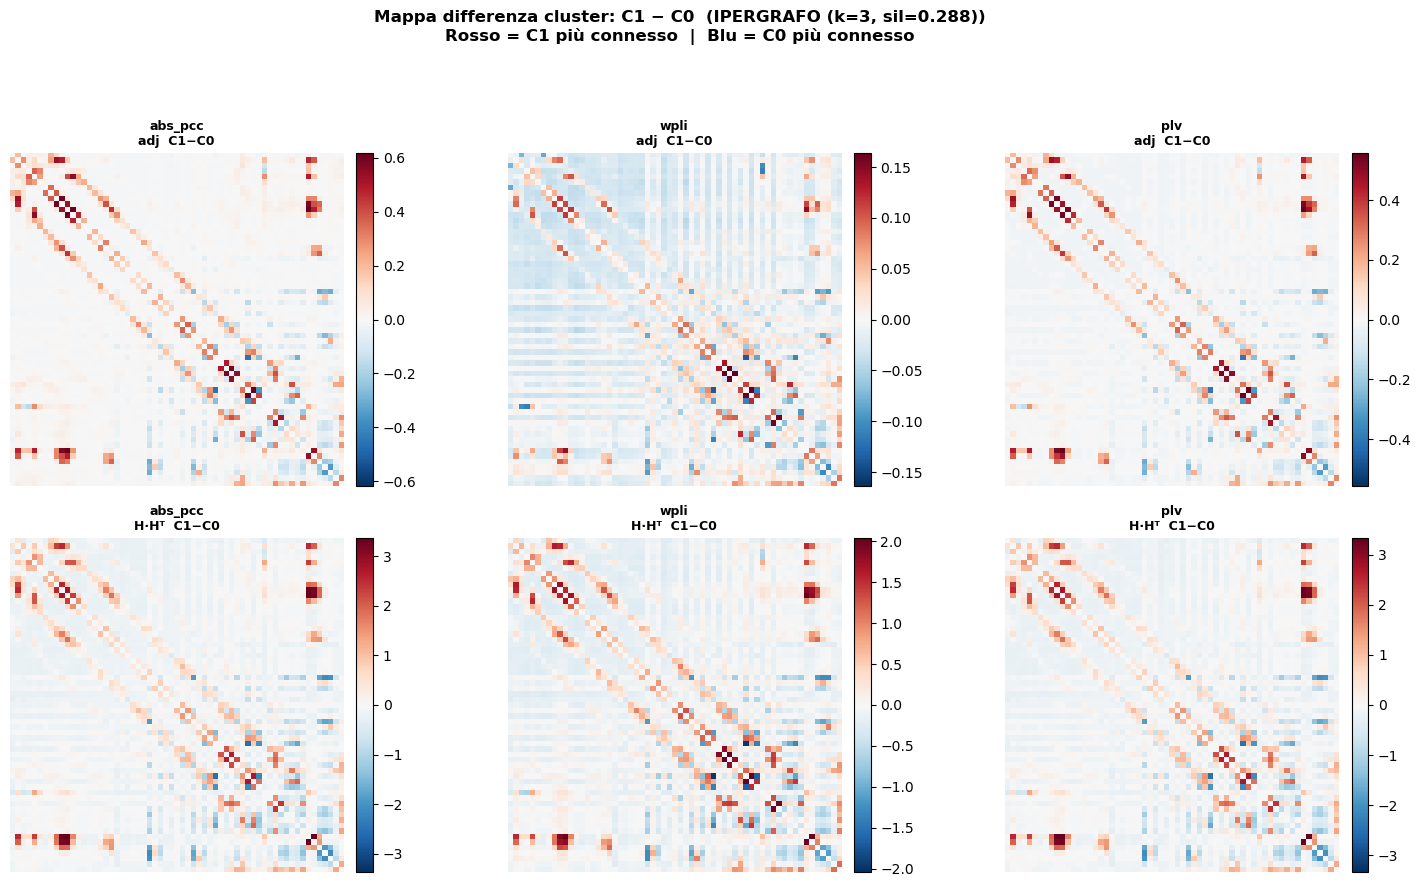

In [30]:
# Due cluster più grandi del top clustering
sizes    = sorted([(c, int((LABELS_TOP == c).sum())) for c in range(k_top)],
                  key=lambda x: -x[1])
c_a, c_b = sorted([sizes[0][0], sizes[1][0]])   # ordine per indice cluster
log.info(f'Cluster grandi: C{c_a} (n={sizes[0][1] if sizes[0][0]==c_a else sizes[1][1]}) '
         f'vs C{c_b} (n={sizes[1][1] if sizes[1][0]==c_b else sizes[0][1]})')

def cluster_mean_mat(feats, subjs, cluster_idx):
    subj_c = [SUBJ_TOP[i] for i in range(len(SUBJ_TOP)) if LABELS_TOP[i] == cluster_idx]
    mats   = [vec_to_sym(feats[subjs.index(s)]) for s in subj_c if s in subjs]
    return np.mean(mats, axis=0) if mats else None

# ── Row 0: adj diff per metrica | Row 1: H·Hᵀ diff (solo abs_pcc) ────────────
n_met = len(METRICS_COMPARE)
fig, axes = plt.subplots(2, n_met, figsize=(5 * n_met, 9))
fig.suptitle(
    f'Mappa differenza cluster: C{c_b} − C{c_a}  ({top_src})\n'
    f'Rosso = C{c_b} più connesso  |  Blu = C{c_a} più connesso',
    fontsize=12, fontweight='bold'
)

for col, m in enumerate(METRICS_COMPARE):
    feats_m, subjs_m = ALL_FEATS_G[m]
    adj_a = cluster_mean_mat(feats_m, subjs_m, c_a)
    adj_b = cluster_mean_mat(feats_m, subjs_m, c_b)

    # ── Row 0: adj diff ───────────────────────────────────────────────────────
    ax = axes[0, col]
    if adj_a is not None and adj_b is not None:
        diff   = adj_b - adj_a
        d_lim  = np.abs(diff).max() * 0.9
        im = ax.imshow(diff, cmap='RdBu_r', vmin=-d_lim, vmax=d_lim, interpolation='nearest')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
        ax.set_title(f'{m}\nadj  C{c_b}−C{c_a}', fontsize=9, fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'N/D', ha='center', va='center', transform=ax.transAxes)
    ax.axis('off')

    # ── Row 1: H·Hᵀ diff per ogni metrica ───────────────────────────────────
    ax2 = axes[1, col]
    if m in ALL_FEATS_H:
        _hht_feats, _hht_subjs = ALL_FEATS_H[m]
        hht_a = cluster_mean_mat(_hht_feats, _hht_subjs, c_a)
        hht_b = cluster_mean_mat(_hht_feats, _hht_subjs, c_b)
        if hht_a is not None and hht_b is not None:
            diff_h = hht_b - hht_a
            d_h    = np.abs(diff_h).max() * 0.9
            im2 = ax2.imshow(diff_h, cmap='RdBu_r', vmin=-d_h, vmax=d_h, interpolation='nearest')
            plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.03)
            ax2.set_title(f'{m}\nH·Hᵀ  C{c_b}−C{c_a}', fontsize=9, fontweight='bold')
        else:
            ax2.text(0.5, 0.5, 'N/D', ha='center', va='center', transform=ax2.transAxes)
    else:
        ax2.text(0.5, 0.5, 'H·Hᵀ\nsolo abs_pcc', ha='center', va='center',
                 transform=ax2.transAxes, fontsize=9, color='grey', style='italic')
    ax2.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(FIG_DIR / 'eeg16_cluster_diff_map.png', dpi=150, bbox_inches='tight')
plt.show()


## §12 — Metriche qualità segnale per cluster

Per ogni soggetto dal segnale raw medio: **varianza** (potenza), **kurtosi** (proxy artefatti muscolari, >3 = code pesanti), **potenza gamma 30-60 Hz** (tipica EMG).
Se i cluster differiscono su queste metriche → la separazione è driven da qualità segnale, non da IS.

14:56:39 INFO     Soggetti con qualità segnale: 74


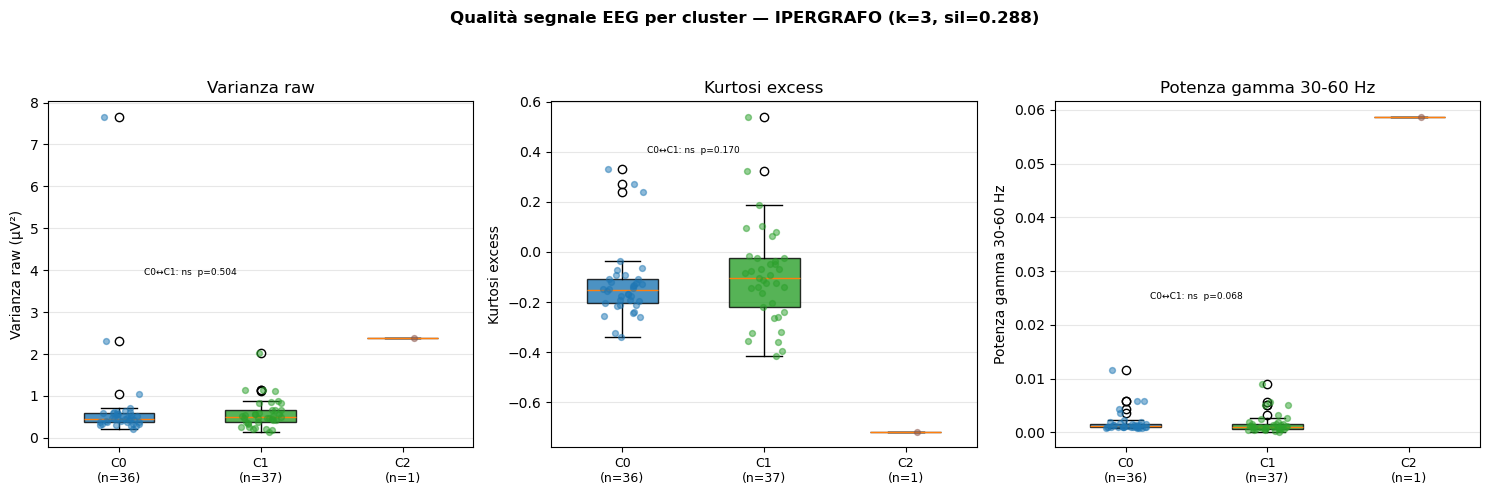


── Qualità segnale per cluster (IPERGRAFO (k=3, sil=0.288)) ──

  Cluster 0  (n=36):
    Varianza raw (µV²): mean=0.7202  std=1.2375  [0.2179, 7.6547]
    Kurtosi excess: mean=-0.1315  std=0.1430  [-0.3394, 0.3322]
    Potenza gamma 30-60 Hz: mean=0.0019  std=0.0021  [0.0008, 0.0116]

  Cluster 1  (n=37):
    Varianza raw (µV²): mean=0.5789  std=0.3594  [0.1510, 2.0362]
    Kurtosi excess: mean=-0.0972  std=0.1945  [-0.4134, 0.5382]
    Potenza gamma 30-60 Hz: mean=0.0017  std=0.0018  [0.0002, 0.0090]

  Cluster 2  (n=1):
    Varianza raw (µV²): mean=2.3839  std=nan  [2.3839, 2.3839]
    Kurtosi excess: mean=-0.7166  std=nan  [-0.7166, -0.7166]
    Potenza gamma 30-60 Hz: mean=0.0587  std=nan  [0.0587, 0.0587]


In [31]:
from scipy.stats import kurtosis as scipy_kurtosis
from scipy.signal import welch

FS         = 256
GAMMA_LOW  = 30
GAMMA_HIGH = 60

# ── Calcola metriche qualità per soggetto ─────────────────────────────────────
rows_q = []
for i, sid in enumerate(SUBJ_RAW):
    x = MEAN_RAW[i]   # (61, 384)

    var_mean   = float(np.var(x, axis=1).mean())
    kurt_mean  = float(np.mean(scipy_kurtosis(x, axis=1, fisher=True)))

    gamma_pows = []
    for ch in range(N_CHAN):
        f, psd = welch(x[ch], fs=FS, nperseg=min(128, N_SAMP))
        mask   = (f >= GAMMA_LOW) & (f <= GAMMA_HIGH)
        gamma_pows.append(float(psd[mask].mean()) if mask.any() else 0.0)
    gamma_mean = float(np.mean(gamma_pows))

    rows_q.append({'sid': sid, 'variance': var_mean,
                   'kurtosis': kurt_mean, 'gamma_power': gamma_mean})

df_qual = pd.DataFrame(rows_q)
df_qual['cluster'] = df_qual['sid'].apply(
    lambda s: int(LABELS_TOP[SUBJ_TOP.index(s)]) if s in SUBJ_TOP else np.nan
)
df_qual.dropna(subset=['cluster'], inplace=True)
df_qual['cluster'] = df_qual['cluster'].astype(int)
log.info(f'Soggetti con qualità segnale: {len(df_qual)}')

# ── Boxplot 1×3 ───────────────────────────────────────────────────────────────
QUAL_COLS = [
    ('variance',    'Varianza raw (µV²)'),
    ('kurtosis',    'Kurtosi excess'),
    ('gamma_power', 'Potenza gamma 30-60 Hz'),
]
COLORS_TOP_Q = plt.cm.tab10(np.linspace(0, 0.5, k_top))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Qualità segnale EEG per cluster — {top_src}', fontsize=12, fontweight='bold')

for ax, (col, label) in zip(axes, QUAL_COLS):
    data = [df_qual[df_qual['cluster'] == c][col].values for c in range(k_top)]
    bp   = ax.boxplot(data, patch_artist=True, widths=0.5, notch=False)
    for patch, color in zip(bp['boxes'], COLORS_TOP_Q):
        patch.set_facecolor(color); patch.set_alpha(0.8)

    # Overlay punti
    for c, d in enumerate(data):
        jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(d))
        ax.scatter(np.full(len(d), c + 1) + jitter, d,
                   color=COLORS_TOP_Q[c], s=18, alpha=0.5, zorder=3)

    ax.set_xticklabels([f'C{c}\n(n={len(data[c])})' for c in range(k_top)], fontsize=9)
    ax.set_title(label.split(' (')[0]); ax.set_ylabel(label)
    ax.grid(axis='y', alpha=0.3)

    # p-value Mann-Whitney su tutte le coppie
    all_flat = np.concatenate([d for d in data if len(d)])
    y_top = np.percentile(all_flat, 99) if len(all_flat) else 1
    for off, (ci, cj) in enumerate([(ci, cj) for ci in range(k_top) for cj in range(ci+1, k_top)]):
        if len(data[ci]) >= 2 and len(data[cj]) >= 2:
            _, pval = mannwhitneyu(data[ci], data[cj], alternative='two-sided')
            star = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
            ax.annotate(f'C{ci}↔C{cj}: {star}  p={pval:.3f}',
                        xy=((ci + cj) / 2 + 1, y_top * (1.02 + 0.06 * off)),
                        fontsize=6.5, ha='center')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(FIG_DIR / 'eeg16_signal_quality_per_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Stampa stats ──────────────────────────────────────────────────────────────
print(f'\n── Qualità segnale per cluster ({top_src}) ──')
for c in range(k_top):
    sub = df_qual[df_qual['cluster'] == c]
    print(f'\n  Cluster {c}  (n={len(sub)}):')
    for col, label in QUAL_COLS:
        print(f'    {label}: mean={sub[col].mean():.4f}  std={sub[col].std():.4f}'
              f'  [{sub[col].min():.4f}, {sub[col].max():.4f}]')
